# JPEG AI as a Threat to Deepfake Detection
Lorenzo Pizzi 2187091

## Setup

Installs dependencies, clones the JPEG AI reference software, compiles C++ entropy coding extensions, and applies compatibility patches.

In [1]:
# Environment Architecture 
# JPEG AI's codec requires numpy 1.x; transformers/torch/detector require
# numpy 2.x. They cannot coexist in the same Python environment without breakage. So we split:
#   • main kernel → numpy 2.x (Colab standard for detector, evaluation)
#   • codec JPEG AI     → islated venv /content/jpegai_venv with numpy 1.x

import subprocess, sys, os

# System's dependencies 
!apt-get update -qq
!apt-get install -yq doxygen graphviz git-lfs
!git lfs install

# Clone the JPEG AI repository 
!rm -rf /content/jpeg_ai
!git clone https://gitlab.com/wg1/jpeg-ai/jpeg-ai-reference-software.git /content/jpeg_ai
!git -C /content/jpeg_ai lfs fetch
!git -C /content/jpeg_ai lfs checkout

# isolated venv for codec JPEG AI (numpy 1.x)
!pip install -q virtualenv
JPEG_AI_PYTHON = '/content/jpegai_venv/bin/python'
if not os.path.exists(JPEG_AI_PYTHON):
    subprocess.check_call([sys.executable, '-m', 'virtualenv',
                           '--system-site-packages', '/content/jpegai_venv'])

# Installation of needed packets in the venv 
_venv_pkgs = ['numpy==1.26.4', 'scipy==1.13.1', 'setuptools', 'wheel',
              'pybind11', 'einops', 'addict', 'commentjson',
              'compressai', 'gputil', 'nvidia-ml-py3']
_critical  = {'numpy==1.26.4', 'scipy==1.13.1', 'pybind11'}
_skipped   = []
for _pkg in _venv_pkgs:
    _r = subprocess.run([sys.executable, '-m', 'pip', '--python', JPEG_AI_PYTHON,
                         'install', '-q', _pkg],
                        capture_output=True, text=True)
    if _r.returncode != 0:
        if _pkg in _critical:
            print(f'ERRORE — pacchetto critico {_pkg} non installato:')
            print(_r.stdout[-800:])
            print(_r.stderr[-1500:])
            raise RuntimeError(f'Installazione venv fallita su {_pkg}.')
        _skipped.append(_pkg)
        print(f'Nota: {_pkg} saltato (non critico).')
if _skipped:
    print(f'Pacchetti opzionali saltati: {_skipped}')
print('venv codec JPEG AI pronto.')


!pip install -q "Pillow>=10.4" "transformers==4.44.2" timm safetensors accelerate

# Compile C++ extentions with python of the venv 
os.chdir('/content/jpeg_ai')

setup_code = '''
from setuptools import setup
from pybind11.setup_helpers import Pybind11Extension, build_ext
ext_modules = [
    Pybind11Extension("ans",
        ["src/codec/entropy_coding/cpp_exts/mans/ans.cpp",
         "src/codec/entropy_coding/cpp_exts/mans/compressor.cpp",
         "src/codec/entropy_coding/cpp_exts/mans/decompressor.cpp"],
        extra_compile_args=["-O3", "-fopenmp", "-std=c++14", "-fPIC"],
        extra_link_args=["-fopenmp"]),
    Pybind11Extension("ec_direct",
        ["src/codec/entropy_coding/cpp_exts/direct/py_ec_lib_direct.cpp",
         "src/codec/entropy_coding/cpp_exts/direct/ec_lib_direct.cpp"],
        extra_compile_args=["-O3", "-fopenmp", "-std=c++14", "-fPIC"],
        extra_link_args=["-fopenmp"]),
]
setup(name="jpeg_ai_ext", ext_modules=ext_modules, cmdclass={"build_ext": build_ext})
'''
with open('setup_ext.py', 'w') as f:
    f.write(setup_code)

subprocess.check_call([JPEG_AI_PYTHON, 'setup_ext.py', '-q', 'build_ext', '--inplace'])
!mv ans*.so       src/codec/entropy_coding/lib_wrappers/mans/ 2>/dev/null || true
!mv ec_direct*.so src/codec/entropy_coding/lib_wrappers/direct/ 2>/dev/null || true
print('Setup completed.')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
doxygen is already the newest version (1.9.1-2ubuntu2).
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 66 not upgraded.
Git LFS initialized.
Cloning into '/content/jpeg_ai'...
remote: Enumerating objects: 2238, done.
remote: Counting objects: 100% (440/440), done.
remote: Compressing objects: 100% (287/287), done.
remote: Total 2238 (delta 175), reused 358 (delta 144), pack-reused 1798 (from 1)
Receiving objects: 100% (2238/2238), 4.58 MiB | 20.55 MiB/s, done.
Resolving deltas: 100% (656/656), done.
Filtering content: 100% (151/151), 1.65 GiB | 64.12 MiB/s, done.
fetch: Fetching reference refs/heads/main

In [2]:
# Patch 1: pynvml 
from pathlib import Path
import shutil

gpu_file = Path('/content/jpeg_ai/src/codec/coding_tools/profiler/gpu_memory_usage.py')
text = gpu_file.read_text()
if 'try:' not in text:
    text = text.replace(
        'from pynvml.smi import nvidia_smi',
        'try:\n    from pynvml.smi import nvidia_smi\n'
        'except ImportError:\n'
        '    class nvidia_smi:\n'
        '        @classmethod\n'
        '        def getInstance(cls):\n'
        '            class _D:\n'
        "                def DeviceQuery(self, *a): return {'gpu': [{'fb_memory_usage': {'total': 1, 'used': 0}}]}\n"
        '            return _D()'
    )
    gpu_file.write_text(text)

# Patch 2: ptflops — stub package
ptflops_dir = Path('/content/jpeg_ai/ptflops')
ptflops_dir.mkdir(exist_ok=True)
shutil.rmtree(ptflops_dir / '__pycache__', ignore_errors=True)

(ptflops_dir / 'flops_counter.py').write_text(
    "CUSTOM_MODULES_MAPPING = {}\n"
    "def flops_to_string(x, **kw): return '0 GMac'\n"
    "def get_model_complexity_info(*a, **kw): return '0 GMac', '0 M'\n"
    "def ptflops_get_model_bounds(*a, **kw): return None\n"
    "conv_flops_counter_hook = None\n"
)
(ptflops_dir / '__init__.py').write_text(
    "from . import flops_counter\n"
    "def get_model_complexity_info(*a, **kw): return '0 GMac', '0 M'\n"
)

# Patch 3: binarizers.py — numpy scalar fix 
binarizers_file = Path('/content/jpeg_ai/src/codec/entropy_coding/binarizers.py')
text = binarizers_file.read_text()
old_line = 'value = int(bypass_coder.decode(1, max_symbol_value=max_v))'
if old_line in text:
    new_line = ('_dv = bypass_coder.decode(1, max_symbol_value=max_v); '
                'value = int(_dv.item() if hasattr(_dv, "item") else _dv)')
    binarizers_file.write_text(text.replace(old_line, new_line))
    print('Patch binarizers.py: OK')
else:
    print('Patch binarizers.py: already applied or not found')

print('All patches applied')


Patch binarizers.py: OK
All patches applied


## Imports

In [3]:
import os
import sys
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from google.colab import drive

import torch
from transformers import pipeline as hf_pipeline

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score

from scipy.fft import fft2, fftshift, dctn
import scipy.ndimage as ndi

## Globals

In [4]:
drive.mount('/content/drive')

SEED = 42
np.random.seed(SEED)

# Device
DEVICE = 0 if torch.cuda.is_available() else -1
print(f'Dispositivo: {"GPU (cuda:0)" if DEVICE == 0 else "CPU"}')

# Folders for persistence (all on Drive to keep data between sessions)
DRIVE_ROOT   = Path('/content/drive/MyDrive/CV_Project')
DATA_DIR     = DRIVE_ROOT / 'data'
DATASET_DIR  = DATA_DIR / 'raw' / 'openfake_dataset'
MANIFEST_DIR = DATA_DIR / 'manifests'
PNG_DIR      = DATA_DIR / 'png_cache'
COMP_DIR     = DATA_DIR / 'compressed'
RESULTS_DIR  = DRIVE_ROOT / 'results' / 'phase1'
SPECTRA_CACHE  = RESULTS_DIR / 'freq_spectra_cache.npz'
DCT_CACHE = RESULTS_DIR / 'freq_dct_cache.npz'

MANIFEST_PATH = MANIFEST_DIR / 'dataset.csv'
COMP_MANIFEST = MANIFEST_DIR / 'compression.csv'

for _d in [DATA_DIR, MANIFEST_DIR, PNG_DIR, COMP_DIR, RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# JPEG AI 
JPEG_AI_DIR    = Path('/content/jpeg_ai')
JPEG_AI_PYTHON = '/content/jpegai_venv/bin/python'   # python del venv numpy 1.x
JPEG_AI_CFG    = ['cfg/tools_on.json', 'cfg/profiles/base.json']
JPEG_AI_ENV    = {**os.environ, 'TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD': '1'}
JPEG_AI_ALIGN = 256

# Experiments
TARGET_BPP  = [0.12, 0.25, 0.50, 1.00]
N_PER_CLASS = 100
N_DCT = 50   # immagini per gruppo

# Dataset and Detectors
KAGGLE_DATASET = 'sanketghadge1/openfake-data-20k-img'
IMAGE_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
PRIMARY  = 'Corvi2023' # used as primary detector

CROP_SIZE = 256

print('Globals configurated.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dispositivo: GPU (cuda:0)
Globals configurated.


## Data

**Data pipeline (5 steps):**
1. Download OpenFake 20k from Kaggle → skipped if already on Drive
2. Build a manifest CSV with path, label, and split for each image
3. Sample `N_PER_CLASS` images per class from the test split
4. Compress each image with JPEG AI at the target BPP levels defined in Globals
5. Verify compression results and load `comp_df`

In [5]:
# Dataset download (if not already present)
if DATASET_DIR.exists() and any(DATASET_DIR.iterdir()):
    print(f'Dataset già presente: {DATASET_DIR}')
else:
    print('Scaricamento da Kaggle...')
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    result = subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', KAGGLE_DATASET,
        '-p', str(DATASET_DIR.parent),
        '--unzip', '--force',
    ], capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError('Download failed. Controlla ~/.kaggle/kaggle.json.')
    print('Download completed.')

Dataset già presente: /content/drive/MyDrive/CV_Project/data/raw/openfake_dataset


In [6]:
# Build or Load the Manifest 
# Manifest is a csv with one row per image:
#   image_id | path | label | label_id | split
#
# label_id: 0 = real, 1 = fake
# If the manifest already exists on Drive, load it without rescanning.

if MANIFEST_PATH.exists():
    df = pd.read_csv(str(MANIFEST_PATH))
    print(f'Manifest loaded: {len(df)} images')
else:
    print('Building manifest (only listing, no image opening)...')
    rows = []
    for split in ['train', 'test']:
        for label in ['real', 'fake']:
            folder = DATASET_DIR / split / label
            if not folder.exists():
                continue
            files = [p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS]
            for img_path in tqdm(files, desc=f'{split}/{label}'):
                rows.append({
                    'image_id': img_path.stem,
                    'path':     str(img_path),
                    'label':    label,
                    'label_id': 0 if label == 'real' else 1,
                    'split':    split,
                })

    df = pd.DataFrame(rows)
    df.to_csv(str(MANIFEST_PATH), index=False)
    print(f'Manifest saved: {len(df)} immagini')

print('\nSummary of the dataset:')
print(df.groupby(['split', 'label']).size().to_string())


Manifest loaded: 19944 images

Summary of the dataset:
split  label
test   fake     1987
       real     2002
train  fake     7948
       real     8007


In [7]:
# Build a test_sample including already processed images

test_df   = df[df['split'] == 'test'].copy()
real_pool = test_df[test_df['label'] == 'real']
fake_pool = test_df[test_df['label'] == 'fake']

_comp_path = MANIFEST_DIR / 'compression.csv'
if _comp_path.exists():
    try:
        _existing_ids = set(pd.read_csv(str(_comp_path))['image_id'].astype(str).unique())
    except Exception:
        _existing_ids = set()
else:
    _existing_ids = set()

def _build_sample(pool, existing_ids, n_per_class, seed):
    already    = pool[pool['image_id'].astype(str).isin(existing_ids)]
    remaining  = pool[~pool['image_id'].astype(str).isin(existing_ids)]
    n_new      = max(0, n_per_class - len(already))
    new        = remaining.sample(min(len(remaining), n_new), random_state=seed)
    return pd.concat([already, new])

test_sample = pd.concat([
    _build_sample(real_pool, _existing_ids, N_PER_CLASS, SEED),
    _build_sample(fake_pool, _existing_ids, N_PER_CLASS, SEED),
]).reset_index(drop=True)

n_real = (test_sample['label'] == 'real').sum()
n_fake = (test_sample['label'] == 'fake').sum()
n_old  = test_sample['image_id'].astype(str).isin(_existing_ids).sum()
n_new  = len(test_sample) - n_old
print(f'Subset for compression + evaluation:')
print(f'  real: {n_real} | fake: {n_fake} | total: {len(test_sample)}')
print(f'  already processed: {n_old} | new to compress: {n_new}')
print(f'  predicted encoder calls: {n_new} × {len(TARGET_BPP)} = {n_new * len(TARGET_BPP)}')


Subset for compression + evaluation:
  real: 100 | fake: 100 | total: 200
  already processed: 200 | new to compress: 0
  predicted encoder calls: 0 × 4 = 0


In [8]:
# JPEG AI Compression Loop

if COMP_MANIFEST.exists():
    try:
        comp_df = pd.read_csv(str(COMP_MANIFEST))
        done = {
            (str(r['image_id']), round(float(r['target_bpp']), 4))
            for _, r in comp_df.iterrows()
            if Path(r['recon_path']).exists()
        }
        print(f'Resumed: {len(done)} image×BPP pairs already completed.')
    except pd.errors.EmptyDataError:
        print('compression.csv is empty — starting from scratch.')
        COMP_MANIFEST.unlink()
        comp_df = pd.DataFrame()
        done    = set()
else:
    comp_df = pd.DataFrame()
    done    = set()

new_rows = []
errors   = []
t_start  = time.time()

for _, row in tqdm(test_sample.iterrows(), total=len(test_sample), desc='Immagini'):
    img_id = str(row['image_id'])
    src    = Path(row['path'])

    with Image.open(src) as _src_im:
        orig_w, orig_h = _src_im.size

    aligned_w = max(JPEG_AI_ALIGN, ((orig_w + JPEG_AI_ALIGN - 1) // JPEG_AI_ALIGN) * JPEG_AI_ALIGN)
    aligned_h = max(JPEG_AI_ALIGN, ((orig_h + JPEG_AI_ALIGN - 1) // JPEG_AI_ALIGN) * JPEG_AI_ALIGN)
    needs_pad = (aligned_w != orig_w or aligned_h != orig_h)

    png_path = PNG_DIR / f'{img_id}.png'
    _cached_size = Image.open(png_path).size if png_path.exists() else None
    if not png_path.exists() or (needs_pad and _cached_size != (aligned_w, aligned_h)):
        _img = Image.open(src).convert('RGB')
        if needs_pad:
            _padded = Image.new('RGB', (aligned_w, aligned_h), (128, 128, 128))
            _padded.paste(_img, (0, 0))
            _padded.save(png_path)
        else:
            _img.save(png_path)

    for bpp in TARGET_BPP:
        key = (img_id, round(bpp, 4))
        if key in done:
            continue

        tag      = f'bpp_{bpp:.2f}'
        bit_path = COMP_DIR / tag / 'bitstream' / f'{img_id}.bits'
        rec_path = COMP_DIR / tag / 'recon'     / f'{img_id}.png'
        bit_path.parent.mkdir(parents=True, exist_ok=True)
        rec_path.parent.mkdir(parents=True, exist_ok=True)

        # The codec run with python of isolated venv (numpy 1.x)
        enc = subprocess.run([
            JPEG_AI_PYTHON, '-m', 'src.reco.coders.encoder',
            str(png_path), str(bit_path),
            '--set_target_bpp', str(int(round(bpp * 100))),
            '--cfg', *JPEG_AI_CFG,
        ], cwd=JPEG_AI_DIR, env=JPEG_AI_ENV, capture_output=True, text=True)

        if enc.returncode != 0:
            errors.append(f'{img_id} BPP={bpp}: {enc.stderr[-300:]}')
            continue

        dec = subprocess.run([
            JPEG_AI_PYTHON, '-m', 'src.reco.coders.decoder',
            str(bit_path), str(rec_path),
        ], cwd=JPEG_AI_DIR, env=JPEG_AI_ENV, capture_output=True, text=True)

        if dec.returncode != 0:
            errors.append(f'{img_id} BPP={bpp} decode: {dec.stderr[-300:]}')
            continue

        # BPP computed on originals pixels 
        measured_bpp = round((bit_path.stat().st_size * 8) / (orig_w * orig_h), 4)

        new_rows.append({
            'image_id':     img_id,
            'label':        row['label'],
            'label_id':     int(row['label_id']),
            'target_bpp':   bpp,
            'measured_bpp': measured_bpp,
            'recon_path':   str(rec_path),
        })
        done.add(key)

        if len(new_rows) % 10 == 0:
            comp_df = pd.concat([comp_df, pd.DataFrame(new_rows)], ignore_index=True)
            comp_df.to_csv(str(COMP_MANIFEST), index=False)
            new_rows = []

if new_rows:
    comp_df = pd.concat([comp_df, pd.DataFrame(new_rows)], ignore_index=True)
    comp_df.to_csv(str(COMP_MANIFEST), index=False)

elapsed = round(time.time() - t_start)
print(f'Compression completed in {elapsed//60} min {elapsed%60} s')
print(f'Total records: {len(comp_df)} / {len(test_sample)*len(TARGET_BPP)} expected')
if errors:
    print(f'Errors ({len(errors)}): showing the first 3:')
    for e in errors[:3]:
        print(f'  {e}')


Resumed: 800 image×BPP pairs already completed.


Immagini:   0%|          | 0/200 [00:00<?, ?it/s]

Compression completed in 0 min 1 s
Total records: 800 / 800 expected


In [9]:
# Verify compression results and show BPP summary
comp_df = pd.read_csv(str(COMP_MANIFEST))
print(f'comp_df: {len(comp_df)} rows')
total_expected = len(test_sample) * len(TARGET_BPP)
missing_files  = [r['recon_path'] for _, r in comp_df.iterrows()
                  if not Path(r['recon_path']).exists()]

print(f'Progress: {len(comp_df)}/{total_expected} pairs ({100*len(comp_df)//total_expected}%)')
if missing_files:
    print(f'WARNING: {len(missing_files)} missing reconstructed files — rerun the previous cell.')
else:
    print('All reconstructed files are present on disk.')

print('\nBPP measured vs target (mean ± std):')
print(comp_df.groupby('target_bpp')['measured_bpp'].agg(['mean', 'std']).round(4).to_string())

comp_df: 800 rows
Progress: 800/800 pairs (100%)
All reconstructed files are present on disk.

BPP measured vs target (mean ± std):
              mean     std
target_bpp                
0.12        0.1218  0.0089
0.25        0.2581  0.0181
0.50        0.5113  0.0372
1.00        1.0137  0.0951


## Network

Loads CLIP-Det  

**Detector**: `ClipBased-SyntheticImageDetection`  
CLIP features + linear classifier trained on real and AI-generated images. Input: RGB image → Output: LLR (log-likelihood ratio); LLR > 0 → synthetic.  
Produces three scores: `clipdet_latent10k_plus`, `Corvi2023`, `fusion`.  
Primary detector: **Corvi2023** — the only score exceeding AUC > 0.75 on uncompressed OpenFake.

In [11]:
# Detector: CLIP-Det (Cozzolino et al., CVPRW 2024)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'open_clip_torch'], check=True)

CLIPDET_DIR = Path('/content/ClipBased-SyntheticImageDetection')
if not CLIPDET_DIR.exists():
    subprocess.run(['git', 'clone', '--depth=1',
        'https://github.com/grip-unina/ClipBased-SyntheticImageDetection.git',
        str(CLIPDET_DIR)], check=True)
    print('CLIP-Det: repo cloned')
else:
    print('CLIP-Det: repo already exists')

_weights_ok = (CLIPDET_DIR / 'weights' / 'clipdet_latent10k_plus' / 'weights.pth').exists()
if not _weights_ok:
    subprocess.run(['git', 'lfs', 'pull'], cwd=str(CLIPDET_DIR), check=True)
    print('CLIP-Det: weights downloaded')
else:
    print('CLIP-Det: weights already present')

# Smoke test
_test_csv = Path('/content/clipdet_smoke.csv')
_test_out = Path('/content/clipdet_smoke_out.csv')
pd.DataFrame({'filename': [test_sample.iloc[0]['path']]}).to_csv(str(_test_csv), index=False)

_r = subprocess.run([
    sys.executable, str(CLIPDET_DIR / 'main.py'),
    '--in_csv', str(_test_csv), '--out_csv', str(_test_out), '--device', 'cuda:0',
], capture_output=True, text=True, cwd=str(CLIPDET_DIR))

if _r.returncode != 0:
    print('ERRORE smoke test:')
    print(_r.stderr[-500:])
else:
    _smoke = pd.read_csv(str(_test_out))
    print(f'Output columns: {list(_smoke.columns)}')
    print('Detector (CLIP-Det) ready')

CLIP-Det: repo already exists
CLIP-Det: weights downloaded
Output columns: ['filename', 'clipdet_latent10k_plus', 'Corvi2023', 'fusion']
Detector (CLIP-Det) ready


## Evaluation

**Phase 1 — Baseline evaluation under compression:**
1. Evaluate CLIP-Det on **original** (uncompressed) images → baseline AUC
2. Evaluate on **JPEG AI-reconstructed** images at each BPP level
3. Report AUC / Accuracy / F1 as a function of bitrate and plot the degradation curves

Primary detector: **Corvi2023** (only score with AUC > 0.75 on originals). `clipdet_latent10k_plus` and `fusion` reported for completeness.

In [13]:
# Detector: CLIP-Det 
# main.py compute 3 colums in the same inference run:
#   • clipdet_latent10k_plus → detector CLIP-based 
#   • Corvi2023              → detector for images from diffusion models 
#   • fusion                 → fusion of the two
# Score = LLR; soglia LLR>0 → fake. AUC is the attendible metric 
def evaluate_clipdet(image_paths: list, true_labels: list, tag: str = 'eval') -> dict:
    """Returns {column_name: {auc, acc, f1, scores, labels, n}}."""
    in_csv  = Path(f'/content/clipdet_{tag}.csv')
    out_csv = Path(f'/content/clipdet_{tag}_out.csv')
    pd.DataFrame({'filename': image_paths}).to_csv(str(in_csv), index=False)

    r = subprocess.run([
        sys.executable, str(CLIPDET_DIR / 'main.py'),
        '--in_csv', str(in_csv), '--out_csv', str(out_csv), '--device', 'cuda:0',
    ], capture_output=True, text=True, cwd=str(CLIPDET_DIR))
    if r.returncode != 0:
        raise RuntimeError(f'CLIP-Det errore:\n{r.stderr[-400:]}')

    res    = pd.read_csv(str(out_csv)).set_index('filename').reindex(image_paths).reset_index()
    labels = np.array(true_labels, dtype=int)
    out    = {}
    for col in [c for c in res.columns if c.lower() != 'filename']:
        scores = res[col].values.astype(float)
        preds  = (scores > 0).astype(int)
        out[col] = {
            'scores': scores, 'labels': labels,
            'auc': float(roc_auc_score(labels, scores)),
            'acc': float(accuracy_score(labels, preds)),
            'f1':  float(f1_score(labels, preds, zero_division=0)),
            'n':   len(labels),
        }
    return out

orig_paths  = [row['path']          for _, row in test_sample.iterrows()]
orig_labels = [int(row['label_id']) for _, row in test_sample.iterrows()]

print(f'=== CLIP-Det — Original ({len(orig_paths)} images) ===')
res_orig2 = evaluate_clipdet(orig_paths, orig_labels, tag='orig')
for col, m in res_orig2.items():
    print(f'  {col:24s} AUC={m["auc"]:.4f}  Acc={m["acc"]:.4f}  F1={m["f1"]:.4f}')
print()

res_bpp2 = {}
for bpp in sorted(TARGET_BPP):
    subset = comp_df[comp_df['target_bpp'].round(4) == round(bpp, 4)].copy()
    paths  = list(subset['recon_path'])
    labels = list(subset['label_id'].astype(int))
    print(f'=== CLIP-Det BPP={bpp}  ({len(paths)} images) ===')
    res_bpp2[bpp] = evaluate_clipdet(paths, labels, tag=f'bpp_{bpp}')
    for col, m in res_bpp2[bpp].items():
        print(f'  {col:24s} AUC={m["auc"]:.4f}  Acc={m["acc"]:.4f}  F1={m["f1"]:.4f}')
    print()

# Table Comparison — AUC (threshold-independent metric, reliable for comparison) 
_cols  = list(res_orig2.keys())   # order: clipdet_latent10k_plus, Corvi2023, fusion
_short = {'clipdet_latent10k_plus': 'CLIP', 'Corvi2023': 'Corvi23', 'fusion': 'fusion'}
_width = 12 + 10 * len(_cols)
print('=' * _width)
print('  COMPARISON DETECTOR — AUC')
print('=' * _width)
_hdr = f'{"BPP":<12}'
for c in _cols:
    _hdr += f' {_short.get(c, c[:9]):>9}'
print(_hdr)
print('-' * _width)
_row = f'{"Original":<12}'
for c in _cols:
    _row += f' {res_orig2[c]["auc"]:>9.4f}'
print(_row)
for bpp in sorted(TARGET_BPP):
    _row = f'{bpp:<12}'
    for c in _cols:
        _row += f' {res_bpp2[bpp][c]["auc"]:>9.4f}'
    print(_row)
print('=' * _width)


=== CLIP-Det — Original (200 images) ===
  clipdet_latent10k_plus   AUC=0.6043  Acc=0.5400  F1=0.4026
  Corvi2023                AUC=0.9289  Acc=0.8400  F1=0.8095
  fusion                   AUC=0.8904  Acc=0.7800  F1=0.7864

=== CLIP-Det BPP=0.12  (200 images) ===
  clipdet_latent10k_plus   AUC=0.4099  Acc=0.4050  F1=0.4936
  Corvi2023                AUC=0.4340  Acc=0.4500  F1=0.5703
  fusion                   AUC=0.4127  Acc=0.4900  F1=0.6531

=== CLIP-Det BPP=0.25  (200 images) ===
  clipdet_latent10k_plus   AUC=0.4203  Acc=0.4450  F1=0.4478
  Corvi2023                AUC=0.6676  Acc=0.5850  F1=0.3664
  fusion                   AUC=0.5217  Acc=0.5100  F1=0.5739

=== CLIP-Det BPP=0.5  (200 images) ===
  clipdet_latent10k_plus   AUC=0.4509  Acc=0.4350  F1=0.3957
  Corvi2023                AUC=0.8736  Acc=0.5950  F1=0.3306
  fusion                   AUC=0.5777  Acc=0.5150  F1=0.5268

=== CLIP-Det BPP=1.0  (200 images) ===
  clipdet_latent10k_plus   AUC=0.4906  Acc=0.4900  F1=0.4000
  Co

  PHASE 1 — AUC for detectors vs compression level
      BPP  clipdet_latent10k_plus  Corvi2023  fusion
Originale                  0.6043     0.9289  0.8904
      1.0                  0.4906     0.9225  0.7090
      0.5                  0.4509     0.8736  0.5777
     0.25                  0.4203     0.6676  0.5217
     0.12                  0.4099     0.4340  0.4127
 AUC<0.5 => inversione counter-forensic (detector anti-predittivo).


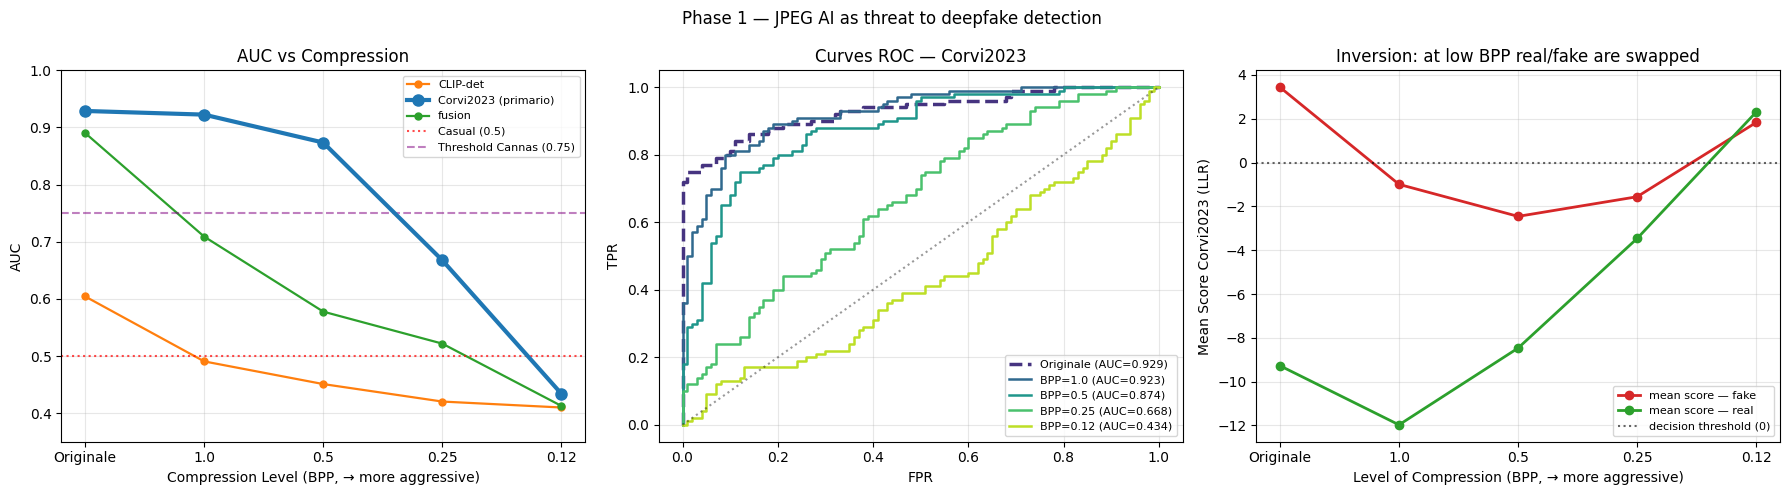

Plots saved:   /content/drive/MyDrive/CV_Project/results/phase1/phase1_results.png
Metrics saved:  /content/drive/MyDrive/CV_Project/results/phase1/phase1_metrics.csv
Detail Corvi2023: /content/drive/MyDrive/CV_Project/results/phase1/phase1_corvi2023.csv


In [14]:
bpp_desc = sorted(TARGET_BPP, reverse=True)          # 1.0 → 0.12 (qualita calante)
x_labels = ['Originale'] + [str(b) for b in bpp_desc]
x_pos    = list(range(len(x_labels)))

detectors = ['clipdet_latent10k_plus', 'Corvi2023', 'fusion']
_style = {
    'clipdet_latent10k_plus': ('CLIP-det',             'tab:orange'),
    'Corvi2023':              ('Corvi2023 (primario)', 'tab:blue'),
    'fusion':                 ('fusion',               'tab:green'),
}

def _auc_series(name):
    return ([res_orig2[name]['auc']] +
            [res_bpp2[b][name]['auc'] for b in bpp_desc])

# Summary Table for AUC per detector and compression level
results_df = pd.DataFrame({'BPP': x_labels})
for d in detectors:
    results_df[d] = _auc_series(d)

print('=' * 65)
print('  PHASE 1 — AUC for detectors vs compression level')
print('=' * 65)
print(results_df.to_string(index=False,
      float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))
print('=' * 65)
print(' AUC<0.5 => inversione counter-forensic (detector anti-predittivo).')
results_df.to_csv(str(RESULTS_DIR / 'phase1_metrics.csv'), index=False)

_prim = [{'BPP': 'Original',
           **{k: res_orig2[PRIMARY][k] for k in ('auc', 'acc', 'f1')}}]
for b in bpp_desc:
    _prim.append({'BPP': b,
                  **{k: res_bpp2[b][PRIMARY][k] for k in ('auc', 'acc', 'f1')}})
pd.DataFrame(_prim).to_csv(str(RESULTS_DIR / 'phase1_corvi2023.csv'), index=False)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 1 — JPEG AI as threat to deepfake detection ',
             fontsize=12)

# 1: AUC vs compression level for each detector (line plot)
ax = axes[0]
for d in detectors:
    name, color = _style[d]
    is_prim = (d == PRIMARY)
    ax.plot(x_pos, _auc_series(d), 'o-', color=color,
            lw=3 if is_prim else 1.6, ms=8 if is_prim else 5,
            zorder=3 if is_prim else 2, label=name)
ax.axhline(0.5,  color='red',    ls=':',  alpha=0.7, label='Casual (0.5)')
ax.axhline(0.75, color='purple', ls='--', alpha=0.5, label='Threshold Cannas (0.75)')
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels)
ax.set(xlabel='Compression Level (BPP, → more aggressive)', ylabel='AUC',
       title='AUC vs Compression', ylim=(0.35, 1.0))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2: ROC curves of the primary detector
ax = axes[1]
palette = cm.viridis(np.linspace(0.15, 0.9, len(bpp_desc) + 1))
fpr, tpr, _ = roc_curve(res_orig2[PRIMARY]['labels'], res_orig2[PRIMARY]['scores'])
ax.plot(fpr, tpr, '--', color=palette[0], lw=2.5,
        label=f'Originale (AUC={res_orig2[PRIMARY]["auc"]:.3f})')
for i, b in enumerate(bpp_desc):
    m = res_bpp2[b][PRIMARY]
    fpr, tpr, _ = roc_curve(m['labels'], m['scores'])
    ax.plot(fpr, tpr, color=palette[i + 1], lw=1.8,
            label=f'BPP={b} (AUC={m["auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.4)
ax.set(xlabel='FPR', ylabel='TPR',
       title=f'Curves ROC — {PRIMARY}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3: Average score (LLR) for real and fake, per compression level, for the primary detector
ax = axes[2]
conds      = [res_orig2[PRIMARY]] + [res_bpp2[b][PRIMARY] for b in bpp_desc]
real_means = [m['scores'][m['labels'] == 0].mean() for m in conds]
fake_means = [m['scores'][m['labels'] == 1].mean() for m in conds]
ax.plot(x_pos, fake_means, 'o-', color='tab:red',   lw=2, ms=6, label='mean score — fake')
ax.plot(x_pos, real_means, 'o-', color='tab:green', lw=2, ms=6, label='mean score — real')
ax.axhline(0, color='k', ls=':', alpha=0.6, label='decision threshold (0)')
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels)
ax.set(xlabel='Level of Compression (BPP, → more aggressive)',
       ylabel=f'Mean Score {PRIMARY} (LLR)',
       title='Inversion: at low BPP real/fake are swapped')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = RESULTS_DIR / 'phase1_results.png'
plt.savefig(str(plot_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Plots saved:   {plot_path}')
print(f'Metrics saved:  {RESULTS_DIR / "phase1_metrics.csv"}')
print(f'Detail {PRIMARY}: {RESULTS_DIR / "phase1_corvi2023.csv"}')

## Frequency-Domain Forensic Analysis

Analysis of how JPEG AI compression modifies the low-level statistical fingerprints exploited by deepfake detectors, explaining the AUC drop observed in Phase 1.

**Approach**:
1. **Average 2D Fourier spectrum** of noise residuals — original vs. compressed × real vs. fake
2. **1D radial power spectrum** — azimuthal average profile (frequency vs. power)
3. **8×8 DCT coefficient distributions** — how JPEG AI alters the block-frequency statistics detectors rely on
4. **Spectral distance vs. AUC drop** — quantify the link between frequency perturbation and detector degradation

In [15]:
# Functions of frequency analysis for Phase 2 (spectra and DCT features)

palette_bpp = {0.12: '#d62728', 0.25: '#ff7f0e', 0.50: '#2ca02c', 1.00: '#1f77b4'}

def _load_gray_crop(img_path: str, size: int = CROP_SIZE) -> np.ndarray:
    """Load in grayscale and crop the central size×size region."""
    img = Image.open(img_path).convert('L')
    arr = np.array(img, dtype=np.float32)
    H, W = arr.shape
    if H < size or W < size:
        arr = np.pad(arr, ((0, max(0, size - H)), (0, max(0, size - W))), mode='reflect')
        H, W = arr.shape
    cy, cx = H // 2, W // 2
    return arr[cy - size // 2 : cy + size // 2, cx - size // 2 : cx + size // 2]

def _noise_residual(arr: np.ndarray, sigma: float = 2.0) -> np.ndarray:
    """
    Noise residual with high-pass Gaussian filter.
    Methodology of Corvi et al. [33] and Mandelli et al. [64] cited in Cannas et al.
    The residual removes the semantic content and isolates low-level fingerprints
    (upsampling artifacts, decoder periodicity) that detectors exploit.
    """
    return arr - ndi.gaussian_filter(arr, sigma=sigma)

def compute_log_spectrum(img_path: str) -> np.ndarray:
    """
    2D log-scale centered power spectrum of the noise residual.
    Hanning window to reduce spectral leakage at the crop edges.
    """
    try:
        arr  = _load_gray_crop(img_path)
        res  = _noise_residual(arr)
        win  = np.outer(np.hanning(CROP_SIZE), np.hanning(CROP_SIZE))
        spec = np.abs(fftshift(fft2(res * win))) ** 2
        return np.log1p(spec)
    except Exception:
        return None

def avg_spectrum_group(paths: list, desc: str = '') -> np.ndarray:
    """Average of the power spectra over a group of images."""
    accum, count = np.zeros((CROP_SIZE, CROP_SIZE), dtype=np.float64), 0
    for p in tqdm(paths, desc=desc, leave=False):
        s = compute_log_spectrum(p)
        if s is not None and s.shape == (CROP_SIZE, CROP_SIZE):
            accum += s
            count  += 1
    return accum / count if count > 0 else None

def radial_profile(spectrum: np.ndarray):
    """Average azimuthal (radial) profile of the 2D spectrum -> 1D curve."""
    H, W   = spectrum.shape
    cy, cx = H // 2, W // 2
    Y, X   = np.ogrid[:H, :W]
    R      = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2).astype(int)
    max_r  = min(cx, cy)
    radial = np.array([spectrum[R == r].mean() if np.any(R == r) else 0.0
                       for r in range(max_r)])
    freqs  = np.arange(max_r) / (2 * max_r)   # Nyquist-normalized [0, 0.5]
    return freqs, radial

def collect_dct_blocks(paths: list, n_sample: int, desc: str = '') -> np.ndarray:
    """DCT coefficients 8x8 over n_sample images (central crop)."""
    rng      = np.random.default_rng(SEED)
    sampled  = rng.choice(paths, size=min(n_sample, len(paths)), replace=False).tolist()
    all_blks = []
    for p in tqdm(sampled, desc=desc, leave=False):
        try:
            arr = _load_gray_crop(p) - 128.0
            H, W = arr.shape
            H = (H // 8) * 8; W = (W // 8) * 8
            arr = arr[:H, :W]
            blocks = arr.reshape(H // 8, 8, W // 8, 8).transpose(0, 2, 1, 3)
            all_blks.append(dctn(blocks, axes=(-2, -1), norm='ortho').reshape(-1, 8, 8))
        except Exception:
            pass
    return np.concatenate(all_blks, axis=0) if all_blks else None

print('Functions of frequency analysis for Phase 2 (spectra and DCT features) loaded.')

Functions of frequency analysis for Phase 2 (spectra and DCT features) loaded.


In [16]:
# Computed average spectra for each group (original real/fake, and compressed real/fake at each BPP).
EXPECTED_GROUPS = (
    ['orig_real', 'orig_fake'] +
    [f'comp_{side}_{bpp}'
     for bpp in sorted(TARGET_BPP)
     for side in ['real', 'fake']]
)

def _build_spectra():
    orig_real_paths = list(test_sample[test_sample['label'] == 'real']['path'])
    orig_fake_paths = list(test_sample[test_sample['label'] == 'fake']['path'])
    print(f'  orig_real: {len(orig_real_paths)} immagini | orig_fake: {len(orig_fake_paths)} immagini')
    out = {
        'orig_real': avg_spectrum_group(orig_real_paths, 'Orig real'),
        'orig_fake': avg_spectrum_group(orig_fake_paths, 'Orig fake'),
    }
    for bpp in sorted(TARGET_BPP):
        sub        = comp_df[np.isclose(comp_df['target_bpp'].values, bpp, atol=1e-3)]
        real_paths = list(sub[sub['label'] == 'real']['recon_path'])
        fake_paths = list(sub[sub['label'] == 'fake']['recon_path'])
        print(f'  BPP={bpp}: {len(real_paths)} real, {len(fake_paths)} fake')
        # Smoke-test
        for _lbl, _paths in [('real', real_paths), ('fake', fake_paths)]:
            if _paths:
                try:
                    from PIL import Image as _PILImage
                    _PILImage.open(_paths[0]).convert('L').close()
                except Exception as _e:
                    print(f'    WARNING: open failed on {_paths[0]}: {_e}')
        out[f'comp_real_{bpp}'] = avg_spectrum_group(real_paths, f'Real BPP={bpp}')
        out[f'comp_fake_{bpp}'] = avg_spectrum_group(fake_paths, f'Fake BPP={bpp}')
        for k in [f'comp_real_{bpp}', f'comp_fake_{bpp}']:
            status = 'OK' if out[k] is not None else 'NONE (0 valid images!)' 
            print(f'    {k}: {status}')
    return out

# Load from cache if available and complete, otherwise compute and save.
_use_cache = False
if SPECTRA_CACHE.exists():
    _tmp = np.load(str(SPECTRA_CACHE), allow_pickle=False)
    _missing = [k for k in EXPECTED_GROUPS if k not in _tmp.files]
    if _missing:
        print(f'Cache incomplete — missing {len(_missing)} groups: {_missing}')
        print('Recomputing...')
    else:
        _use_cache = True

if _use_cache:
    _loaded = np.load(str(SPECTRA_CACHE), allow_pickle=False)
    spectra = {k: _loaded[k] for k in _loaded.files}
    print(f'Cache loaded: {len(spectra)} groups from {SPECTRA_CACHE}')
else:
    print('Computing spectra from scratch:')
    spectra = _build_spectra()
    _to_save = {k: v for k, v in spectra.items() if v is not None}
    if _to_save:
        np.savez_compressed(str(SPECTRA_CACHE), **_to_save)
        print(f'Cache saved: {len(_to_save)} groups in {SPECTRA_CACHE}')
    else:
        print('ERROR: no spectra computed correctly.')

print('\nSummary of groups:')
for k in EXPECTED_GROUPS:
    status = f'shape={spectra[k].shape}' if k in spectra and spectra[k] is not None else 'MANCANTE'
    print(f'  {k:25s}: {status}')

Cache loaded: 10 groups from /content/drive/MyDrive/CV_Project/results/phase1/freq_spectra_cache.npz

Summary of groups:
  orig_real                : shape=(256, 256)
  orig_fake                : shape=(256, 256)
  comp_real_0.12           : shape=(256, 256)
  comp_fake_0.12           : shape=(256, 256)
  comp_real_0.25           : shape=(256, 256)
  comp_fake_0.25           : shape=(256, 256)
  comp_real_0.5            : shape=(256, 256)
  comp_fake_0.5            : shape=(256, 256)
  comp_real_1.0            : shape=(256, 256)
  comp_fake_1.0            : shape=(256, 256)


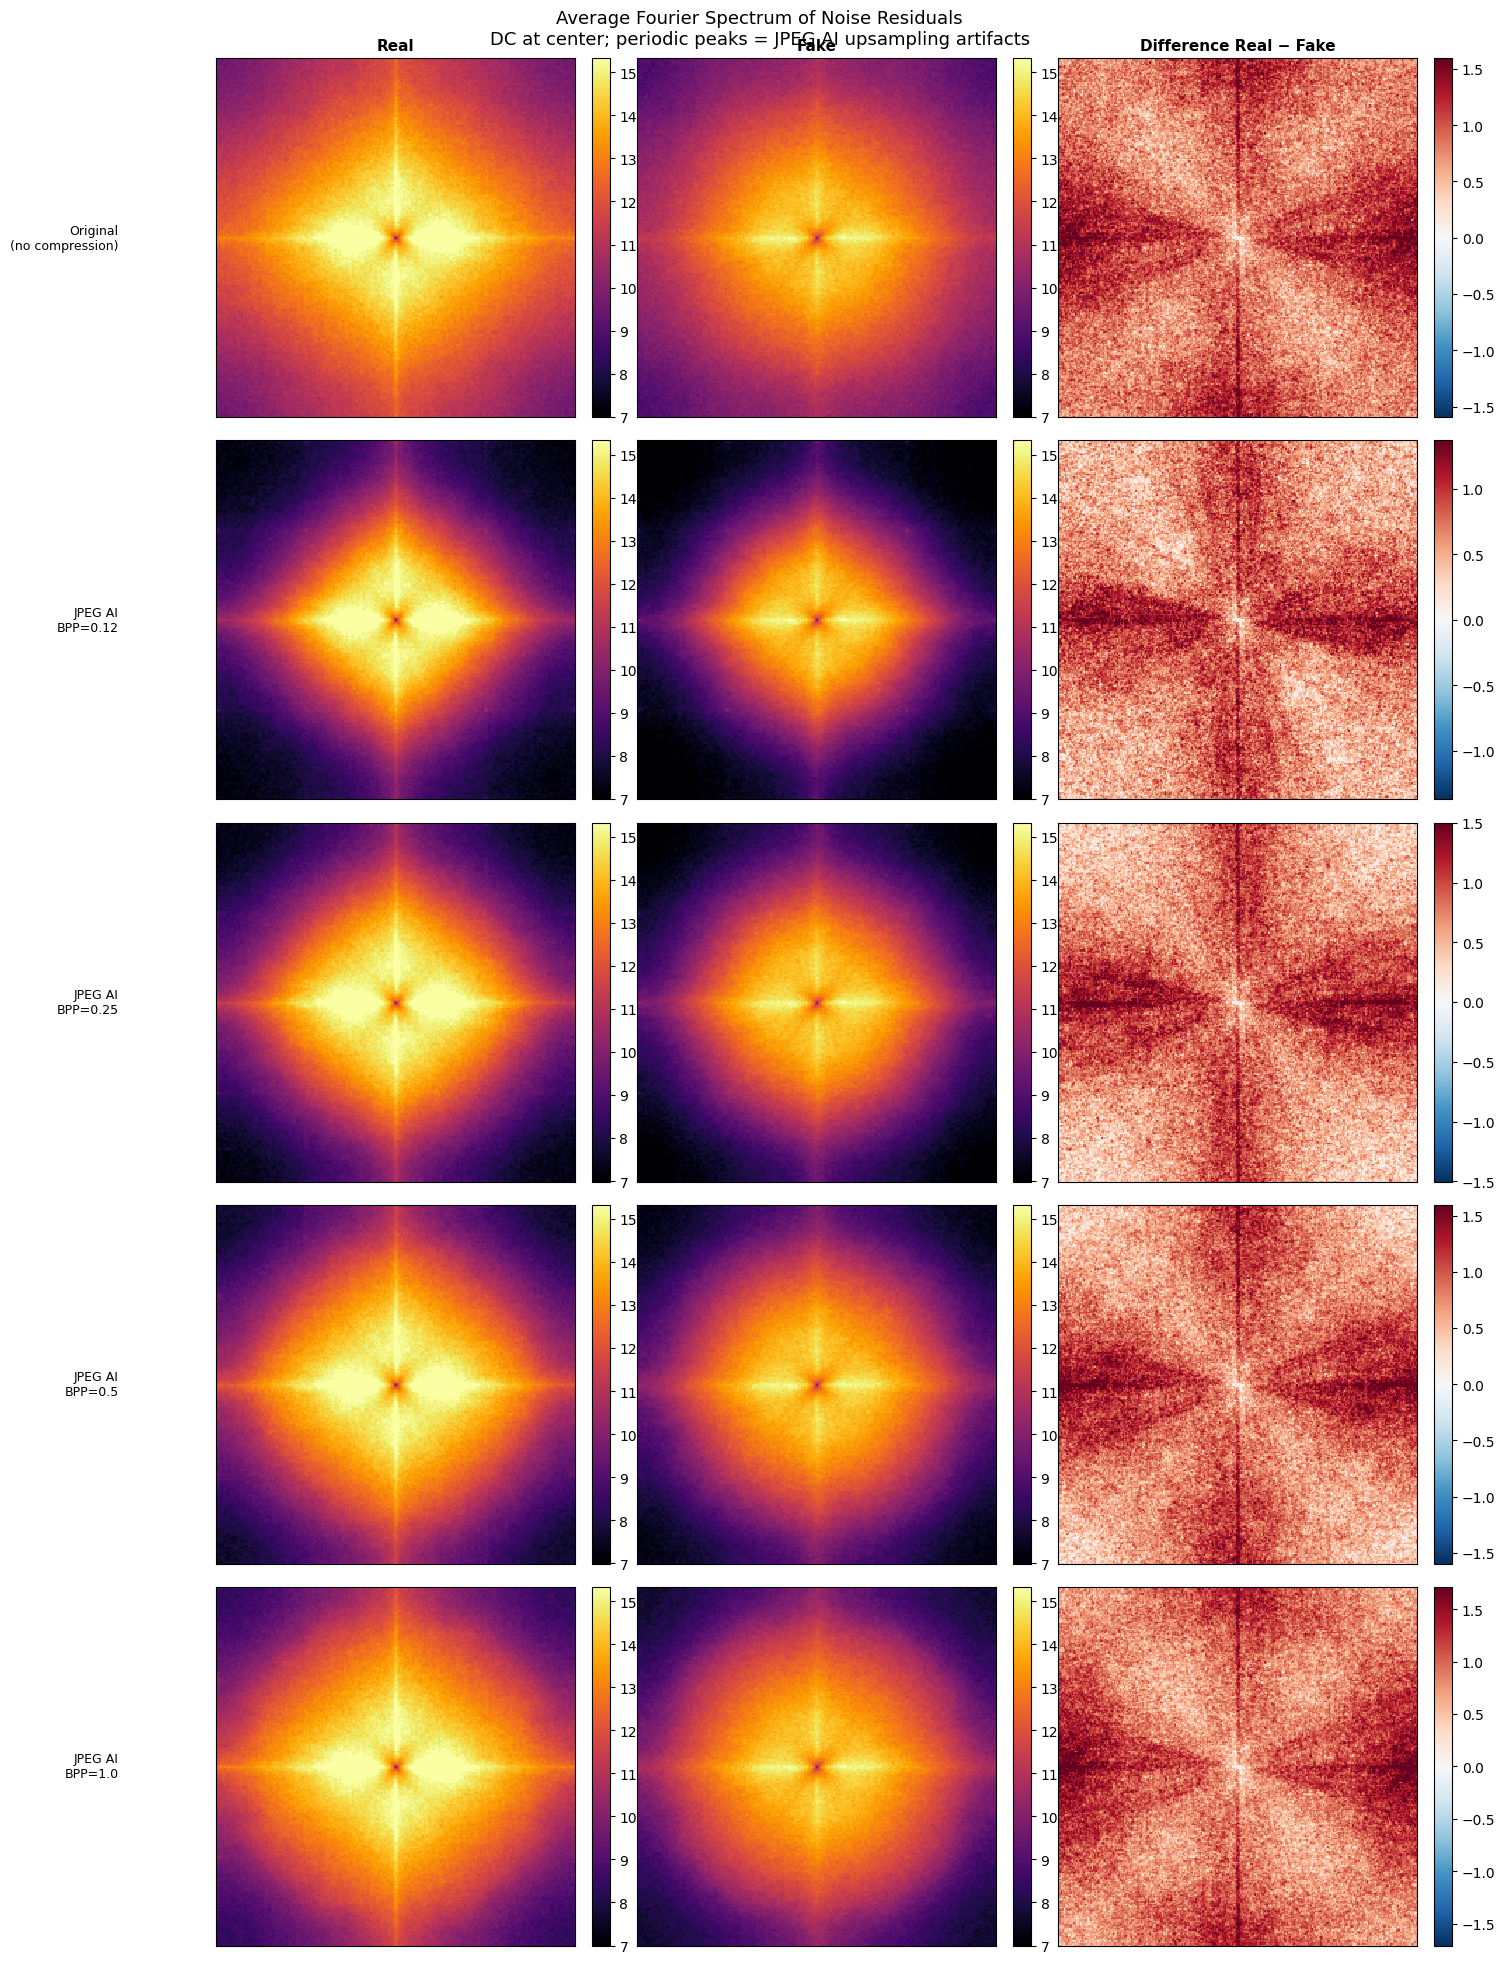

Saved: /content/drive/MyDrive/CV_Project/results/phase1/freq_spectra_2d.png


In [17]:
# 2D Visualization of the average spectra 
bpps_sorted = sorted(TARGET_BPP)
row_labels  = ['Original\n(no compression)'] + [f'JPEG AI\nBPP={b}' for b in bpps_sorted]
col_labels  = ['Real', 'Fake', 'Difference Real − Fake']

fig, axes = plt.subplots(len(row_labels), 3, figsize=(15, 4 * len(row_labels)))
fig.suptitle('Average Fourier Spectrum of Noise Residuals\n'
             'DC at center; periodic peaks = JPEG AI upsampling artifacts', fontsize=13)

_all_vals = np.concatenate([v.ravel() for v in spectra.values() if v is not None])
vmin, vmax = np.percentile(_all_vals, 1), np.percentile(_all_vals, 99)

for ri, rlabel in enumerate(row_labels):
    if ri == 0:
        s_real = spectra.get('orig_real')
        s_fake = spectra.get('orig_fake')
    else:
        bpp    = bpps_sorted[ri - 1]
        s_real = spectra.get(f'comp_real_{bpp}')
        s_fake = spectra.get(f'comp_fake_{bpp}')

    diff = (s_real - s_fake) if (s_real is not None and s_fake is not None) else None

    for ci, (data, clabel) in enumerate(zip([s_real, s_fake, diff], col_labels)):
        ax = axes[ri, ci]
        if data is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        if ci < 2:
            im = ax.imshow(data, cmap='inferno', vmin=vmin, vmax=vmax, interpolation='nearest')
        else:
            lim = np.percentile(np.abs(data), 99)
            im  = ax.imshow(data, cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(clabel, fontsize=11, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(rlabel, fontsize=9, rotation=0, ha='right', va='center', labelpad=70)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
path2d = RESULTS_DIR / 'freq_spectra_2d.png'
plt.savefig(str(path2d), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path2d}')

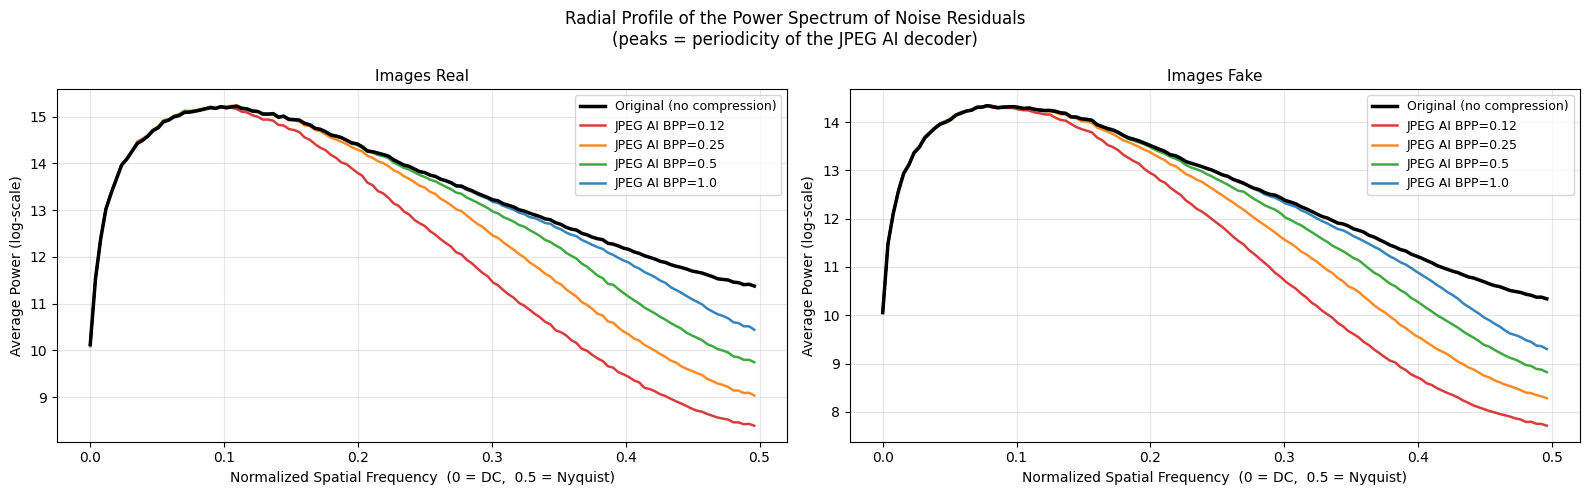

Saved: /content/drive/MyDrive/CV_Project/results/phase1/freq_radial_spectra.png


In [18]:
# Radial profiles of the spectra (1D curves) for real vs fake, per compression level.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Radial Profile of the Power Spectrum of Noise Residuals\n'
             '(peaks = periodicity of the JPEG AI decoder)', fontsize=12)

for col_idx, side in enumerate(['real', 'fake']):
    ax = axes[col_idx]

    s_orig = spectra.get(f'orig_{side}')
    if s_orig is not None:
        freqs, radial = radial_profile(s_orig)
        ax.plot(freqs, radial, 'k-', lw=2.5, label='Original (no compression)', zorder=5)

    for bpp in sorted(TARGET_BPP):
        s = spectra.get(f'comp_{side}_{bpp}')
        if s is not None:
            freqs, radial = radial_profile(s)
            ax.plot(freqs, radial, '-', color=palette_bpp[bpp],
                    lw=1.8, label=f'JPEG AI BPP={bpp}', alpha=0.9)

    ax.set_xlabel('Normalized Spatial Frequency  (0 = DC,  0.5 = Nyquist)', fontsize=10)
    ax.set_ylabel('Average Power (log-scale)', fontsize=10)
    ax.set_title(f'Images {"Real" if side == "real" else "Fake"}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
radial_path = RESULTS_DIR / 'freq_radial_spectra.png'
plt.savefig(str(radial_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {radial_path}')

Carico DCT dalla cache: /content/drive/MyDrive/CV_Project/results/phase1/freq_dct_cache.npz
Caricati 10 gruppi dalla cache.


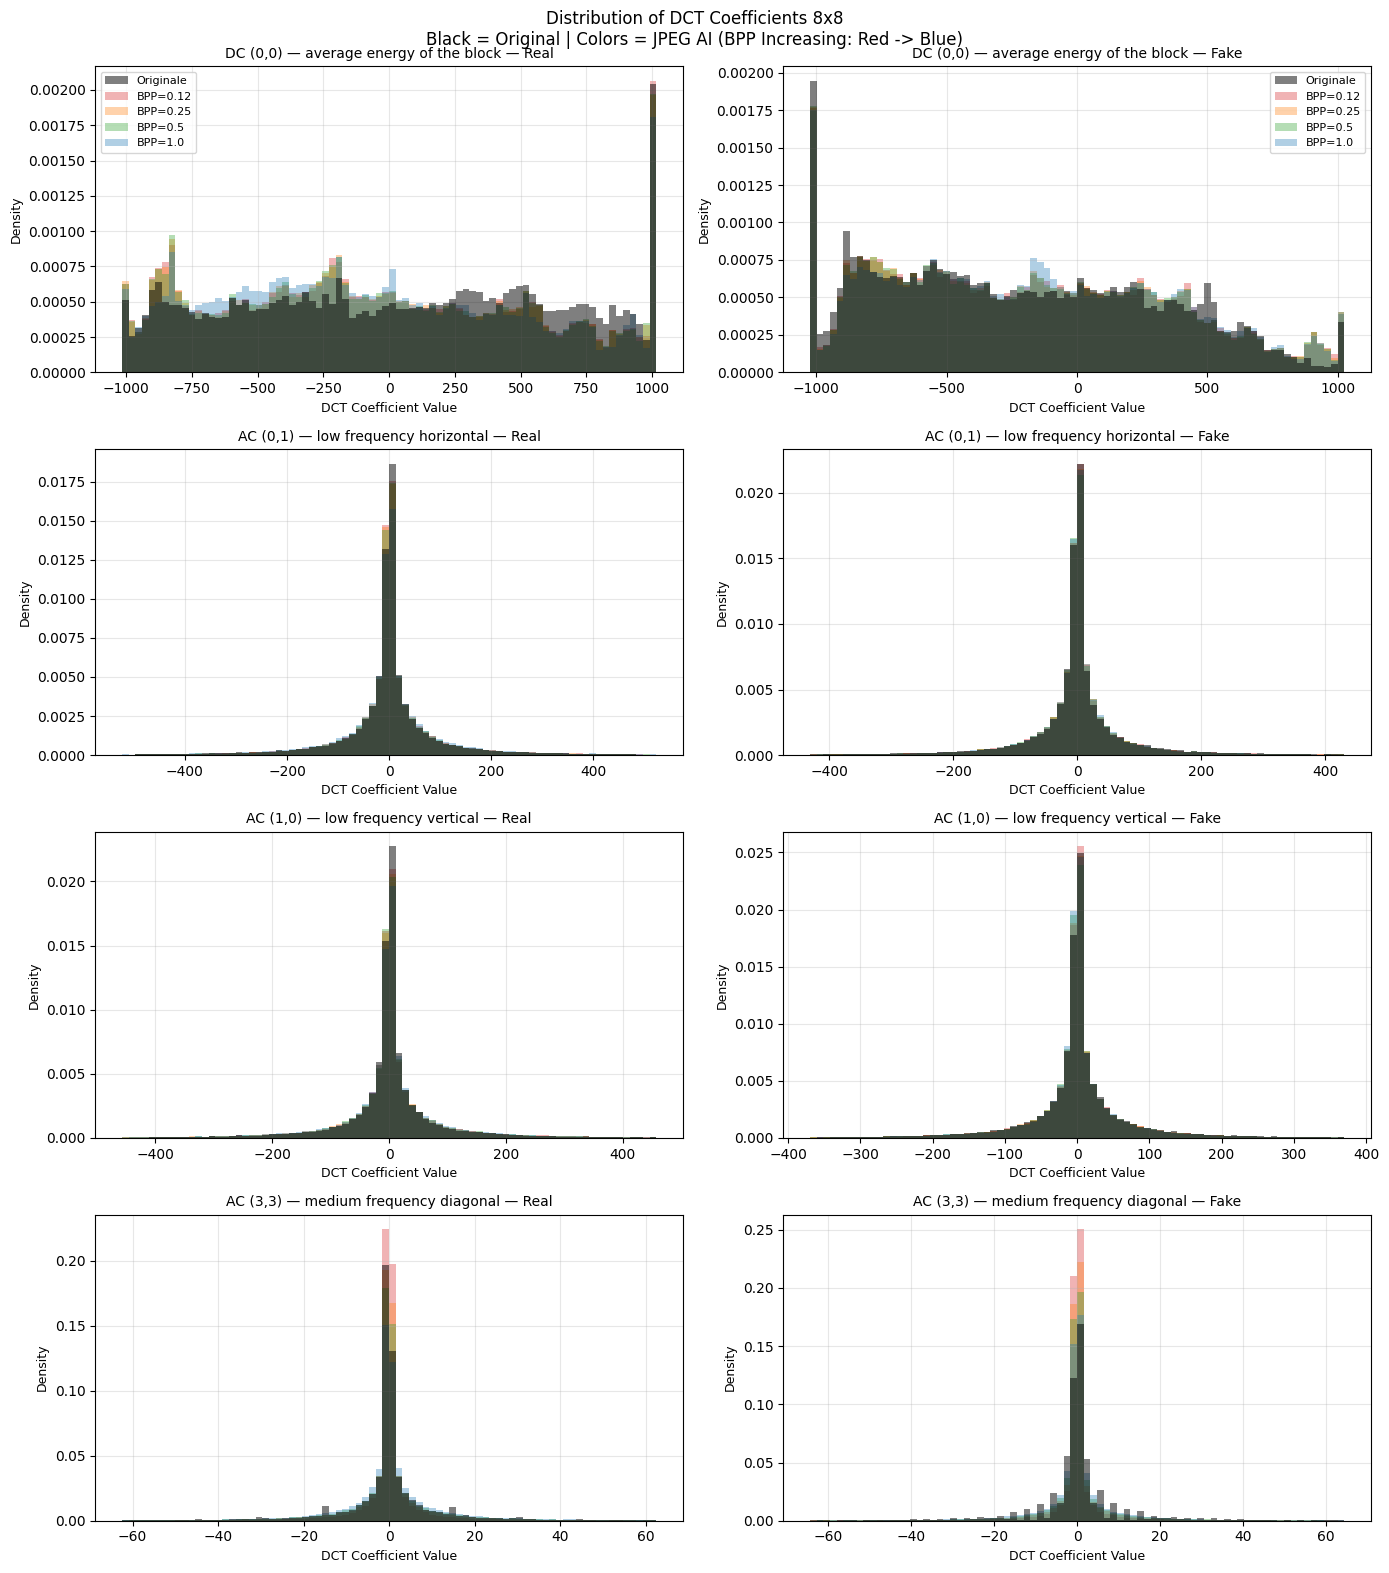

Saved: /content/drive/MyDrive/CV_Project/results/phase1/freq_dct_distributions.png


In [19]:
# Distribution of DCT coefficients over the groups (original real/fake, compressed real/fake at each BPP).

def _build_dct_groups():
    print('Raccolta coefficienti DCT (campione per velocita)...')
    out = {}
    for label in ['real', 'fake']:
        paths = list(test_sample[test_sample['label'] == label]['path'])
        out[f'orig_{label}'] = collect_dct_blocks(paths, N_DCT, f'DCT orig {label}')
    for bpp in sorted(TARGET_BPP):
        for label in ['real', 'fake']:
            sub   = comp_df[(comp_df['target_bpp'].round(4) == round(bpp, 4)) &
                            (comp_df['label'] == label)]
            paths = list(sub['recon_path'])
            out[f'comp_{bpp}_{label}'] = collect_dct_blocks(paths, N_DCT,
                                                             f'DCT {bpp} {label}')
    print('Raccolta completata.')
    return out

if DCT_CACHE.exists():
    print(f'Carico DCT dalla cache: {DCT_CACHE}')
    _loaded   = np.load(str(DCT_CACHE), allow_pickle=False)
    dct_groups = {k: _loaded[k] for k in _loaded.files}
    print(f'Caricati {len(dct_groups)} gruppi dalla cache.')
else:
    dct_groups = _build_dct_groups()
    np.savez_compressed(str(DCT_CACHE), **{k: v for k, v in dct_groups.items() if v is not None})
    print(f'DCT salvati su Drive: {DCT_CACHE}')

# Plot: 4 key DCT coefficients (DC, low-freq orizzontale, low-freq verticale, media freq diagonale)
dct_coords = [
    (0, 0, 'DC (0,0) — average energy of the block'),
    (0, 1, 'AC (0,1) — low frequency horizontal'),
    (1, 0, 'AC (1,0) — low frequency vertical'),
    (3, 3, 'AC (3,3) — medium frequency diagonal'),
]

fig, axes = plt.subplots(len(dct_coords), 2, figsize=(14, 4 * len(dct_coords)))
fig.suptitle('Distribution of DCT Coefficients 8x8\n'
             'Black = Original | Colors = JPEG AI (BPP Increasing: Red -> Blue)', fontsize=12)

for ri, (ci, cj, coeff_name) in enumerate(dct_coords):
    for col_idx, side in enumerate(['real', 'fake']):
        ax = axes[ri, col_idx]

        _all_c = [dct_groups[k][:, ci, cj] for k in dct_groups
                  if dct_groups[k] is not None and side in k]
        if not _all_c:
            continue
        clip = np.percentile(np.abs(np.concatenate(_all_c)), 99)
        bins_range = (-clip, clip)

        orig_key = f'orig_{side}'
        if dct_groups.get(orig_key) is not None:
            vals = dct_groups[orig_key][:, ci, cj]
            ax.hist(vals, bins=80, range=bins_range, density=True,
                    color='black', alpha=0.5, label='Originale', zorder=5)

        for bpp in sorted(TARGET_BPP):
            key = f'comp_{bpp}_{side}'
            if dct_groups.get(key) is not None:
                vals = dct_groups[key][:, ci, cj]
                ax.hist(vals, bins=80, range=bins_range, density=True,
                        color=palette_bpp[bpp], alpha=0.35, label=f'BPP={bpp}')

        ax.set_xlabel('DCT Coefficient Value', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.set_title(f'{coeff_name} — {"Real" if side=="real" else "Fake"}', fontsize=10)
        if ri == 0:
            ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
dct_path = RESULTS_DIR / 'freq_dct_distributions.png'
plt.savefig(str(dct_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {dct_path}')

  SPECTRAL DISTANCE vs AUC DROP — primary detector: Corvi2023
 BPP  dist_real_vs_origreal  dist_fake_vs_origfake  dist_cross_real_origfake  AUC_Corvi2023  AUC_drop
0.12               0.009285               0.008392                  0.006304         0.4340    0.4949
0.25               0.006911               0.006177                  0.004446         0.6676    0.2613
0.50               0.004747               0.004334                  0.003149         0.8736    0.0553
1.00               0.002712               0.002891                  0.002851         0.9225    0.0064

Interpretation:
  dist_real_vs_origreal   : perturbation of the spectral fingerprint of real images by JPEG AI.
  dist_cross_real_origfake: how similar the compressed real images are to the original fake images.
    → high values explain the increase in false positives (AUC drop).
  AUC_drop > 0: degradation of the detector after JPEG AI compression.


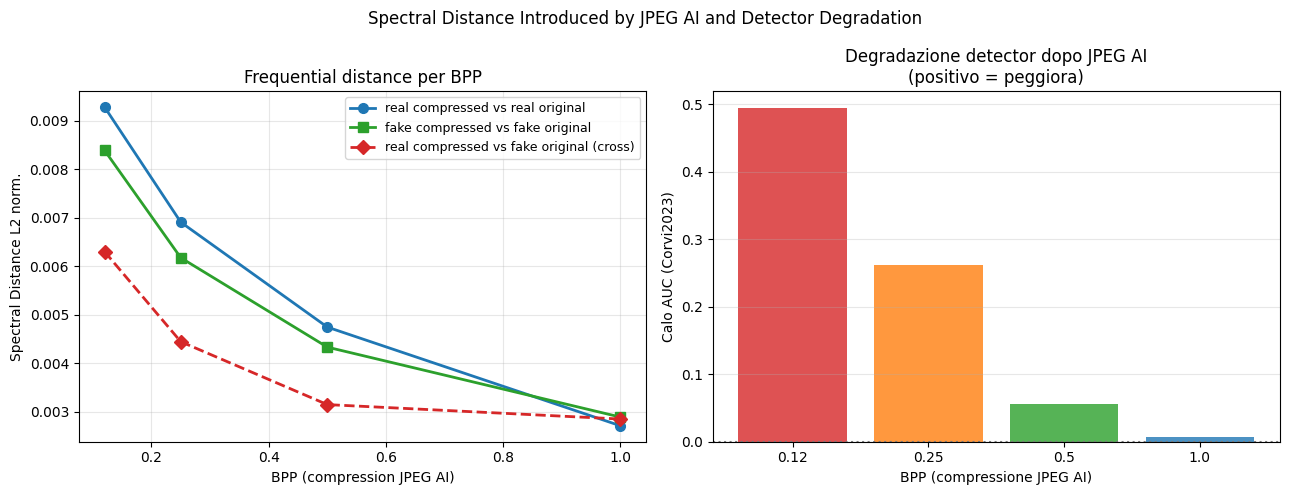

Salvato: /content/drive/MyDrive/CV_Project/results/phase1/freq_spectral_vs_auc.png
CSV:     /content/drive/MyDrive/CV_Project/results/phase1/freq_summary.csv


In [20]:
# Spectral Distance vs AUC Drop — Analysis of the relationship between the spectral perturbation introduced by JPEG AI and the degradation of the primary detector
# For each compression level (BPP), we compute:
#   1. dist_real_vs_origreal : how much JPEG AI shifts the spectral fingerprint of real images (proxy of the perturbation that confuses the detector)
#   2. dist_fake_vs_origfake : how much JPEG AI shifts the spectral fingerprint of fake images (proxy of the perturbation that confuses the detector)
#   3. dist_cross (real→origfake): how similar the compressed real images are to the original fake images (proxy of why detectors classify them as fake)



def spectral_dist(a, b):
    """L2 distance between two spectra, normalized by the number of pixels (to be scale-invariant)."""
    if a is None or b is None:
        return np.nan
    return float(np.linalg.norm(a - b)) / a.size

s_orig_r = spectra.get('orig_real')
s_orig_f = spectra.get('orig_fake')

rows_sum = []
for bpp in sorted(TARGET_BPP):
    s_cr = spectra.get(f'comp_real_{bpp}')
    s_cf = spectra.get(f'comp_fake_{bpp}')

    auc_after  = res_bpp2[bpp][PRIMARY]['auc'] if bpp in res_bpp2 else np.nan
    auc_before = res_orig2[PRIMARY]['auc']

    rows_sum.append({
        'BPP'                    : bpp,
        'dist_real_vs_origreal'  : round(spectral_dist(s_cr, s_orig_r), 6),
        'dist_fake_vs_origfake'  : round(spectral_dist(s_cf, s_orig_f), 6),
        'dist_cross_real_origfake': round(spectral_dist(s_cr, s_orig_f), 6),
        f'AUC_{PRIMARY}'         : round(auc_after, 4),
        'AUC_drop'               : round(auc_before - auc_after, 4),
    })

sum_df = pd.DataFrame(rows_sum)
print('=' * 78)
print(f'  SPECTRAL DISTANCE vs AUC DROP — primary detector: {PRIMARY}')
print('=' * 78)
print(sum_df.to_string(index=False))
print('=' * 78)
print()
print('Interpretation:')
print('  dist_real_vs_origreal   : perturbation of the spectral fingerprint of real images by JPEG AI.')
print('  dist_cross_real_origfake: how similar the compressed real images are to the original fake images.')
print('    → high values explain the increase in false positives (AUC drop).')
print('  AUC_drop > 0: degradation of the detector after JPEG AI compression.')

# Summary Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Spectral Distance Introduced by JPEG AI and Detector Degradation', fontsize=12)

x = sum_df['BPP']
ax1.plot(x, sum_df['dist_real_vs_origreal'],   'o-', color='tab:blue',  lw=2, ms=7,
         label='real compressed vs real original')
ax1.plot(x, sum_df['dist_fake_vs_origfake'],   's-', color='tab:green', lw=2, ms=7,
         label='fake compressed vs fake original')
ax1.plot(x, sum_df['dist_cross_real_origfake'],'D--', color='tab:red',  lw=2, ms=7,
         label='real compressed vs fake original (cross)')
ax1.set_xlabel('BPP (compression JPEG AI)'); ax1.set_ylabel('Spectral Distance L2 norm.')
ax1.set_title('Frequential distance per BPP')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.bar(x.astype(str), sum_df['AUC_drop'], color=list(palette_bpp.values()), alpha=0.8)
ax2.axhline(0, color='gray', ls=':')
ax2.set_xlabel('BPP (compressione JPEG AI)'); ax2.set_ylabel(f'Calo AUC ({PRIMARY})')
ax2.set_title(f'Degradazione detector dopo JPEG AI\n(positivo = peggiora)')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
sum_path = RESULTS_DIR / 'freq_spectral_vs_auc.png'
plt.savefig(str(sum_path), dpi=150, bbox_inches='tight')
plt.show()
sum_df.to_csv(str(RESULTS_DIR / 'freq_summary.csv'), index=False)
print(f'Salvato: {sum_path}')
print(f'CSV:     {RESULTS_DIR / "freq_summary.csv"}')